# Baseline Models — Seville & Larissa (1990–2025)

## What a "baseline model" is, and why it comes before anything fancier

A baseline model is the simplest reasonable model you can fit to a problem — here, predicting
each key climate indicator (annual mean temperature, extreme-heat days, annual precipitation,
extreme-precipitation days) **from year alone**. It exists for one reason: any more sophisticated
model you try later (polynomial fits, ARIMA, a full climate-projection comparison) has to beat
this baseline to justify the extra complexity. If it can't, the simple model was good enough.

Two things make this a *proper* baseline rather than just "linear regression run once":

1. **A naive reference point.** Before trusting the linear-trend model at all, we compare it
   against an even dumber prediction — "assume next year looks like the historical average."
   If linear regression can't beat that, there's no real trend to speak of.
2. **A time-ordered train/test split.** This is a time series, so the test set must be the
   *most recent* years, not a random shuffle — a random split would let the model "see the
   future" indirectly through neighboring years, which defeats the point of holding data out.

This baseline also does double duty: the fitted trend line is exactly the mechanism you'll use
in Week 3 to compare "if current trends continue" against the actual pulled SSP5-8.5 projection
data — so this isn't throwaway scaffolding, it's the first real building block of that comparison.

### Reading MAE, RMSE, and R² together

MAE and RMSE are both plain error magnitudes in the indicator's own units — always ≥ 0, smaller
is better, and RMSE ≥ MAE always (it penalizes big misses more). **R² can be negative**, and that
is not a bug: it measures error relative to a model that always predicts the *test period's own
mean*, not the training mean. If the test years sit above or below the long-run training average
— exactly what happens when a variable is trending — even a reasonable model can score R² < 0,
because it's being compared to a benchmark that has the unfair advantage of already knowing the
test period's average. Treat R² as a sanity check, not the headline number; MAE is what actually
ranks the candidates below.

### Four candidates, not two

An earlier version of this notebook compared only two models: a full-history naive mean and a
full-history OLS trend. Testing a wider set of candidates (5/10/15-year recent-window means,
Theil-Sen robust trends, persistence) showed the full-history OLS trend was, on average, the
*second-worst* of eight candidates tried — old data drags the fitted slope away from recent
behavior, which is exactly what caused the R² = −6.7 blowup on Seville's `days tmax≥35°C` below.
The two consistent winners — restricting the same simple models to a **recent window** rather
than making them more sophisticated — are added below as two extra candidates:
`mean_last_10yr` and `ols_last_15yr`. Recency turned out to matter more than model complexity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.width", 120)


## 1. Load the annual summaries

Both EDA notebooks already export a clean one-row-per-year `annual_summary.csv` — that's the
right input here. No need to go back to daily or 6-hourly data; the baseline model operates on
annual indicators.


In [2]:
SEVILLE_ANNUAL = "../eda_results/eda_outputs/annual_summary.csv"
LARISSA_ANNUAL = "../eda_results/eda_outputs_larissa/annual_summary.csv"
LARISSA_VOLATILITY = "../eda_results/eda_outputs_larissa/larissa_volatility_annual.csv"

sev_annual = pd.read_csv(SEVILLE_ANNUAL).set_index("year").sort_index()
lar_annual = pd.read_csv(LARISSA_ANNUAL).set_index("year").sort_index()

# from Calculating_SPI_for_Larissa.ipynb: min_spi3 (drought depth) and max_week_precip_mm
# (flood intensity), the two-series volatility metric (H4) -- joined in as extra target columns
lar_volatility = pd.read_csv(LARISSA_VOLATILITY, index_col=0).rename_axis("year").sort_index()
lar_annual = lar_annual.join(lar_volatility)

print("Seville annual:", sev_annual.index.min(), "-", sev_annual.index.max(), f"({len(sev_annual)} years)")
print("Larissa annual:", lar_annual.index.min(), "-", lar_annual.index.max(), f"({len(lar_annual)} years)")
print("Larissa volatility columns joined:", list(lar_volatility.columns),
      f"-- {lar_annual[list(lar_volatility.columns)].notna().all(axis=1).sum()} of {len(lar_annual)} years complete")


Seville annual: 1990 - 2025 (36 years)
Larissa annual: 1990 - 2025 (36 years)
Larissa volatility columns joined: ['min_spi3', 'max_week_precip_mm'] -- 36 of 36 years complete


## 2. The baseline-model function

One reusable function, applied to each indicator we care about. For every indicator it fits
**four** candidate baselines on the training years and scores all four on the same held-out
test years:

| Candidate | What it predicts |
|---|---|
| `naive_full_mean` | The mean of *all* training years (the original naive baseline) |
| `mean_last_10yr` | The mean of just the most recent 10 training years |
| `ols_full_history` | An OLS trend (`value ~ year`) fit on *all* training years (the original trend baseline) |
| `ols_last_15yr` | The same OLS trend, fit on only the most recent 15 training years |

The function prints a small MAE/RMSE/R² table per indicator, plots the observed series against
all four candidates, and returns one row of results (used to build the summary table in
section 5).

In [3]:
def baseline_model(df, target_col, city_label, n_test_years=8, recent_window=10, recent_trend_window=15):
    data = df[[target_col]].dropna().sort_index()
    years = data.index.values.astype(float)
    y = data[target_col].values.astype(float)

    split_year = data.index[-n_test_years]
    train_mask = data.index < split_year
    test_mask = ~train_mask

    yrs_train, yrs_test = years[train_mask], years[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # --- four candidate baselines, from simplest to a recency-aware trend ---
    # A quick empirical check across several window lengths and model types showed that
    # fitting on ALL of history (the original naive mean and OLS trend below) is usually
    # *worse* than restricting the same simple models to a recent window -- recency matters
    # more here than model sophistication. mean_last_{recent_window}yr and
    # ols_last_{recent_trend_window}yr are the two winners from that check, added here so
    # the comparison against the original two is part of the notebook itself.
    lr_full = LinearRegression().fit(yrs_train.reshape(-1, 1), y_train)
    lr_recent = LinearRegression().fit(
        yrs_train[-recent_trend_window:].reshape(-1, 1), y_train[-recent_trend_window:]
    )

    candidates = {
        "naive_full_mean": {
            "pred": np.full_like(y_test, y_train.mean()),
            "label": "Naive: full-history mean",
            "color": "#e67e22", "style": "--",
        },
        f"mean_last_{recent_window}yr": {
            "pred": np.full_like(y_test, y_train[-recent_window:].mean()),
            "label": f"Naive: mean of last {recent_window} yrs",
            "color": "#2a9d8f", "style": "--",
        },
        "ols_full_history": {
            "pred": lr_full.predict(yrs_test.reshape(-1, 1)),
            "label": "Linear trend: full history",
            "color": "#c0392b", "style": "-",
        },
        f"ols_last_{recent_trend_window}yr": {
            "pred": lr_recent.predict(yrs_test.reshape(-1, 1)),
            "label": f"Linear trend: last {recent_trend_window} yrs",
            "color": "#264653", "style": "-",
        },
    }

    def scores(pred):
        return {
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": mean_squared_error(y_test, pred) ** 0.5,
            "R2": r2_score(y_test, pred),
        }

    score_table = pd.DataFrame({name: scores(c["pred"]) for name, c in candidates.items()}).T
    score_table = score_table.sort_values("MAE")
    best_model = score_table.index[0]

    print(f"\n=== {city_label} -- {target_col} ===")
    print(f"Train: {int(yrs_train.min())}-{int(yrs_train.max())} ({len(yrs_train)} yrs)  |  "
          f"Test: {int(yrs_test.min())}-{int(yrs_test.max())} ({len(yrs_test)} yrs)")
    print("(R2 is measured against the TEST period's own mean, so a value near 0 or below is")
    print(" common with only 8 test years -- see the markdown note above. MAE is what ranks these.)")
    print(score_table.round(3).to_string())
    if best_model == "naive_full_mean":
        print("Best model by MAE: naive_full_mean -- none of the trend/windowed candidates beat it here.")
    else:
        print(f"Best model by MAE: {best_model} "
              f"(beats naive_full_mean, MAE {score_table.loc['naive_full_mean', 'MAE']:.3f} "
              f"-> {score_table.loc[best_model, 'MAE']:.3f})")

    # --- plot: observed series + all four candidate predictions ---
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(data.index, data[target_col], "o-", color="#4a4a4a", markersize=3, linewidth=1,
            label="Observed", zorder=5)
    ax.axvline(split_year, color="gray", linestyle=":", linewidth=1, label="Train/test split")

    for name in ("naive_full_mean", f"mean_last_{recent_window}yr"):
        c = candidates[name]
        ax.plot(data.index[test_mask], c["pred"], c["style"], color=c["color"],
                linewidth=1.6, label=c["label"])

    fit_years_full = np.arange(yrs_train.min(), yrs_test.max() + 1).reshape(-1, 1)
    fit_years_recent = np.arange(yrs_train[-recent_trend_window], yrs_test.max() + 1).reshape(-1, 1)
    ax.plot(fit_years_full, lr_full.predict(fit_years_full), "-",
            color=candidates["ols_full_history"]["color"],
            linewidth=2, label=candidates["ols_full_history"]["label"])
    ax.plot(fit_years_recent, lr_recent.predict(fit_years_recent), "-",
            color=candidates[f"ols_last_{recent_trend_window}yr"]["color"],
            linewidth=2, label=candidates[f"ols_last_{recent_trend_window}yr"]["label"])

    ax.set_title(f"{city_label} -- {target_col}  (best on held-out MAE: {best_model})")
    ax.legend(fontsize=7.5, loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    out = {"city": city_label, "indicator": target_col, "best_model": best_model}
    for name in candidates:
        out[f"{name}_MAE"] = score_table.loc[name, "MAE"]
        out[f"{name}_RMSE"] = score_table.loc[name, "RMSE"]
        out[f"{name}_R2"] = score_table.loc[name, "R2"]
    out["ols_full_history_slope_per_decade"] = lr_full.coef_[0] * 10
    out[f"ols_last_{recent_trend_window}yr_slope_per_decade"] = lr_recent.coef_[0] * 10
    return out

## 3. Seville — heat-escalation indicators (H1)

Annual mean temperature, annual count of days with tmax ≥ 35°C, annual heatwave days, and annual
tropical nights (tmin ≥ 20°C). The percentile-based heatwave-event columns used to have a few blank
years right at the end of the record — a `reindex` in the EDA notebook's heatwave-detection cell was
still hardcoded to stop at 2020 from before the dataset was extended to 2025, silently dropping
2021–2025 from `heatwave days` / `heatwaves` / `longest (days)`. That's now fixed (the reindex uses
the data's actual year range), so all four indicators are fully populated and safe to hold out a
test set from.


=== Seville -- t2m_mean ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                    MAE   RMSE     R2
mean_last_10yr    0.309  0.404 -0.006
naive_full_mean   0.388  0.452 -0.257
ols_last_15yr     0.410  0.523 -0.687
ols_full_history  0.415  0.530 -0.734
Best model by MAE: mean_last_10yr (beats naive_full_mean, MAE 0.388 -> 0.309)


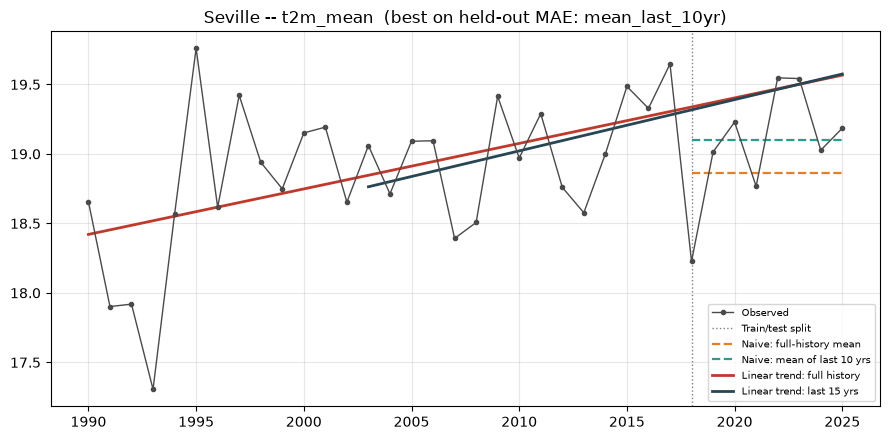


=== Seville -- days tmax≥35°C ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                     MAE    RMSE     R2
naive_full_mean    8.625  11.054 -0.436
mean_last_10yr    14.775  17.419 -2.565
ols_last_15yr     20.575  22.442 -4.918
ols_full_history  24.010  25.607 -6.705
Best model by MAE: naive_full_mean -- none of the trend/windowed candidates beat it here.


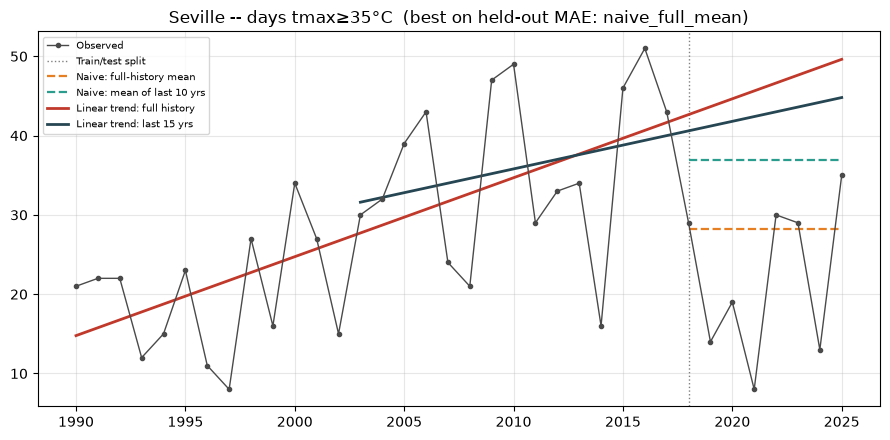


=== Seville -- heatwave days ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                     MAE    RMSE     R2
naive_full_mean    9.027  11.877 -0.004
mean_last_10yr    11.775  13.035 -0.209
ols_last_15yr     13.547  14.747 -0.548
ols_full_history  15.538  16.526 -0.944
Best model by MAE: naive_full_mean -- none of the trend/windowed candidates beat it here.


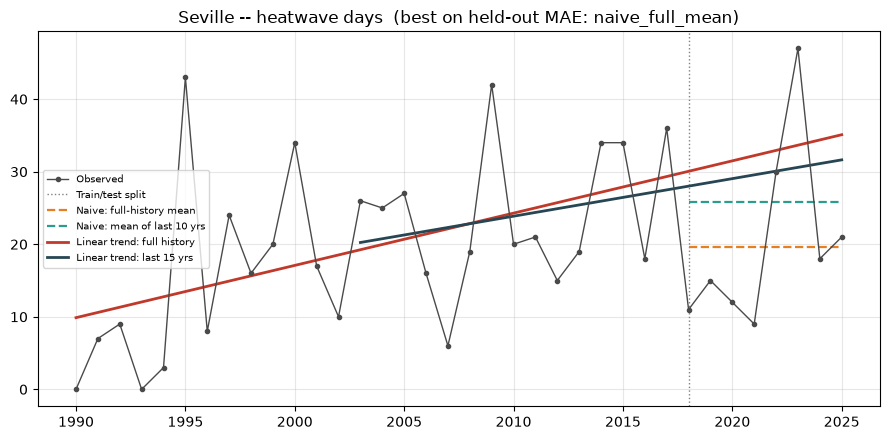


=== Seville -- tropical nights tmin≥20°C ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                     MAE    RMSE     R2
mean_last_10yr    10.425  13.570 -0.851
ols_last_15yr     10.577  13.922 -0.948
naive_full_mean   10.839  14.251 -1.041
ols_full_history  10.884  14.321 -1.061
Best model by MAE: mean_last_10yr (beats naive_full_mean, MAE 10.839 -> 10.425)


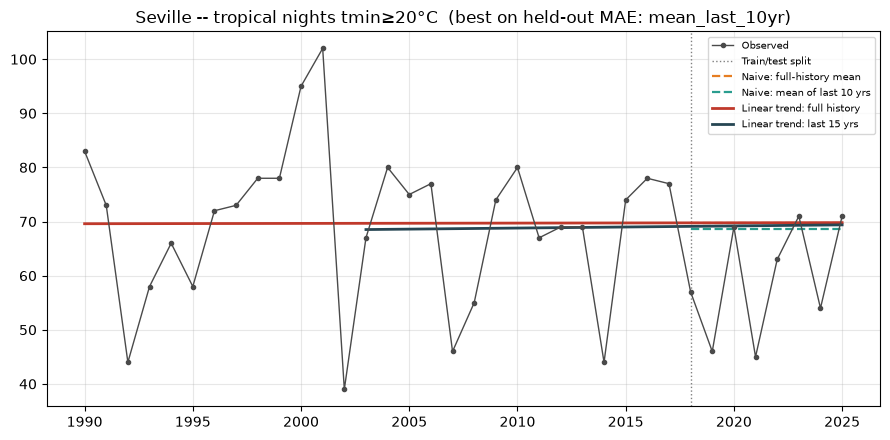

In [4]:
results = []
results.append(baseline_model(sev_annual, "t2m_mean", "Seville"))
results.append(baseline_model(sev_annual, "days tmax≥35°C", "Seville"))
results.append(baseline_model(sev_annual, "heatwave days", "Seville"))
results.append(baseline_model(sev_annual, "tropical nights tmin≥20°C", "Seville"))

## 4. Larissa — precipitation / volatility indicators (H3/H4)

Four indicators: annual scaled precipitation total and annual maximum 1-day rainfall (simple
precipitation baselines), plus the two-series volatility metric now that SPI-3 has been computed
in `Calculating_SPI_for_Larissa.ipynb` — `min_spi3` (drought depth: the driest 3-month window each
year) and `max_week_precip_mm` (flood intensity: the wettest single week each year). Kept as two
parallel series rather than one combined index, consistent with that notebook's design, so each
gets its own baseline-model row below rather than being collapsed into a single number.


=== Larissa -- precip_scaled ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                      MAE     RMSE     R2
ols_last_15yr      94.262  113.754 -0.069
ols_full_history  106.939  132.299 -0.446
mean_last_10yr    122.134  148.836 -0.830
naive_full_mean   136.572  169.632 -1.378
Best model by MAE: ols_last_15yr (beats naive_full_mean, MAE 136.572 -> 94.262)


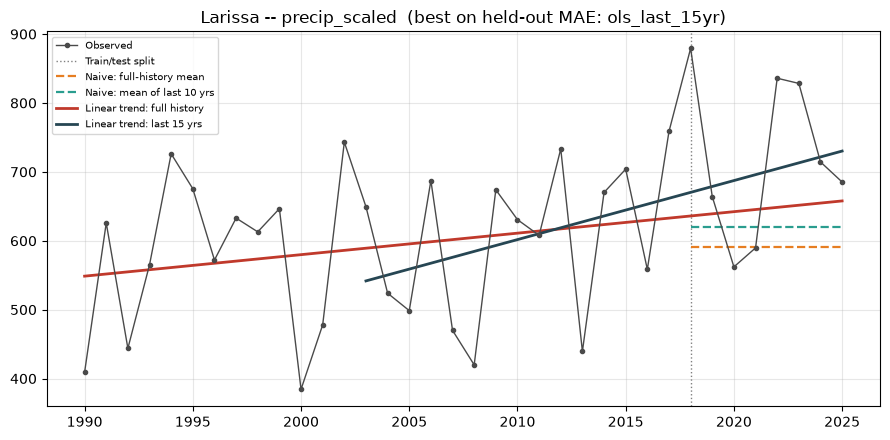


=== Larissa -- max 1-day (mm) ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                     MAE    RMSE     R2
ols_last_15yr     16.024  18.269  0.069
mean_last_10yr    24.801  28.486 -1.264
ols_full_history  24.916  28.600 -1.282
naive_full_mean   25.484  29.173 -1.375
Best model by MAE: ols_last_15yr (beats naive_full_mean, MAE 25.484 -> 16.024)


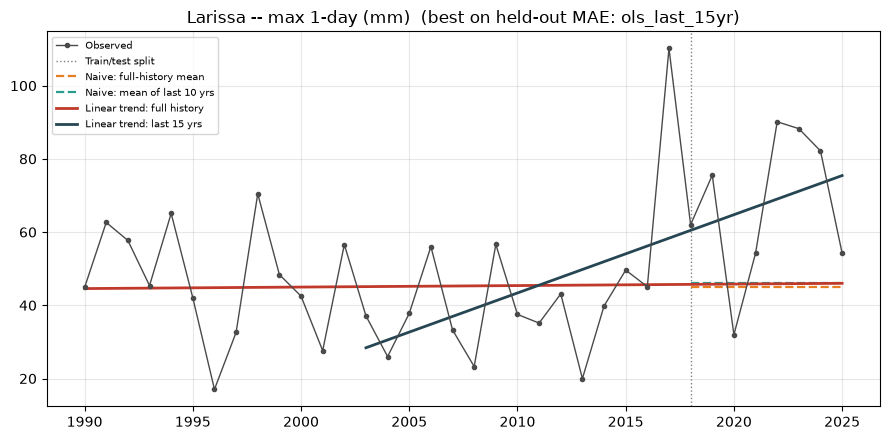


=== Larissa -- min_spi3 ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                    MAE   RMSE     R2
ols_full_history  0.452  0.542 -0.405
naive_full_mean   0.563  0.659 -1.077
mean_last_10yr    0.564  0.660 -1.084
ols_last_15yr     0.673  0.777 -1.885
Best model by MAE: ols_full_history (beats naive_full_mean, MAE 0.563 -> 0.452)


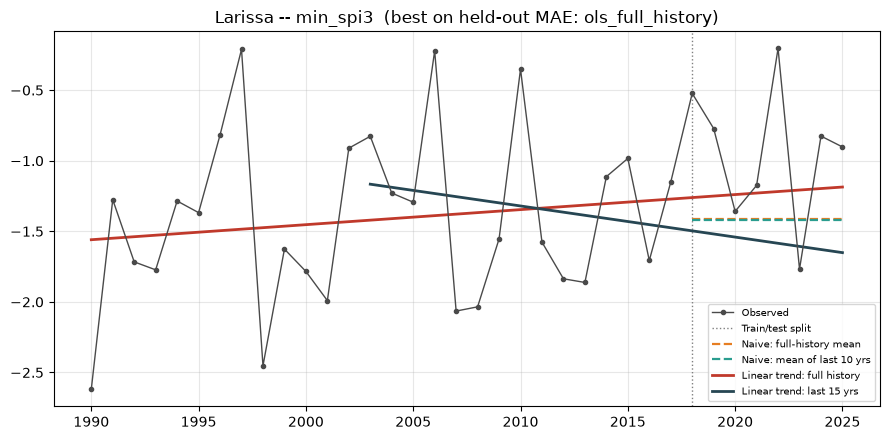


=== Larissa -- max_week_precip_mm ===
Train: 1990-2017 (28 yrs)  |  Test: 2018-2025 (8 yrs)
(R2 is measured against the TEST period's own mean, so a value near 0 or below is
 common with only 8 test years -- see the markdown note above. MAE is what ranks these.)
                     MAE    RMSE     R2
ols_last_15yr     31.460  53.341  0.058
mean_last_10yr    39.543  65.608 -0.425
ols_full_history  41.708  67.205 -0.496
naive_full_mean   42.185  67.596 -0.513
Best model by MAE: ols_last_15yr (beats naive_full_mean, MAE 42.185 -> 31.460)


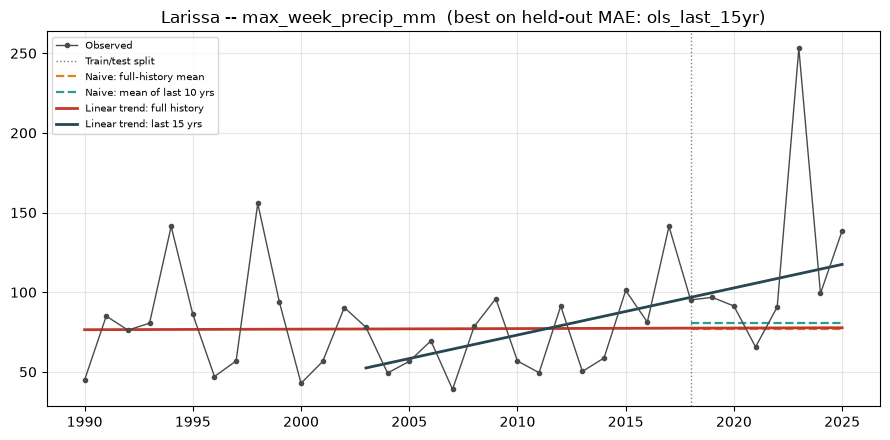

In [5]:
results.append(baseline_model(lar_annual, "precip_scaled", "Larissa"))
results.append(baseline_model(lar_annual, "max 1-day (mm)", "Larissa"))
results.append(baseline_model(lar_annual, "min_spi3", "Larissa"))
results.append(baseline_model(lar_annual, "max_week_precip_mm", "Larissa"))

## 5. Summary table

Each row below is one indicator, with MAE/RMSE/R² for all four candidates side by side and a
`best_model` column marking whichever had the lowest MAE on the held-out years. A model only
"earns its keep" as a baseline if it beats `naive_full_mean` — where none of them do (as with
Seville's `days tmax≥35°C`), that's a legitimate finding, not something to paper over: it means
the indicator doesn't have a clean enough year-over-year signal for any of these simple models
to exploit.

In [6]:
summary = pd.DataFrame(results)

model_cols = ["naive_full_mean", "mean_last_10yr", "ols_full_history", "ols_last_15yr"]
ordered_cols = ["city", "indicator", "best_model"]
for m in model_cols:
    ordered_cols += [f"{m}_MAE", f"{m}_RMSE", f"{m}_R2"]
ordered_cols += ["ols_full_history_slope_per_decade", "ols_last_15yr_slope_per_decade"]
summary = summary[ordered_cols]

print(f"How often each candidate has the lowest MAE, across all {len(summary)} indicators:")
display(summary["best_model"].value_counts().rename_axis("model").to_frame("times_best"))

summary

How often each candidate has the lowest MAE, across all 8 indicators:


,times_best
model,
ols_last_15yr,3
mean_last_10yr,2
naive_full_mean,2
ols_full_history,1


,city,indicator,best_model,naive_full_mean_MAE,naive_full_mean_RMSE,naive_full_mean_R2,mean_last_10yr_MAE,mean_last_10yr_RMSE,mean_last_10yr_R2,ols_full_history_MAE,ols_full_history_RMSE,ols_full_history_R2,ols_last_15yr_MAE,ols_last_15yr_RMSE,ols_last_15yr_R2,ols_full_history_slope_per_decade,ols_last_15yr_slope_per_decade
0,Seville,t2m_mean,mean_last_10yr,0.387538,0.451743,-0.257487,0.308801,0.403998,-0.005725,0.414884,0.530419,-0.733637,0.409722,0.523199,-0.686760,0.327438,0.368843
1,Seville,days tmax≥35°C,naive_full_mean,8.625000,11.053903,-0.435668,14.775000,17.418668,-2.564942,24.010468,25.607417,-6.704672,20.575000,22.442259,-4.917738,9.956212,6.000000
2,Seville,heatwave days,naive_full_mean,9.026786,11.877457,-0.004197,11.775000,13.035145,-0.209494,15.537972,16.525985,-0.944047,13.547321,14.747206,-0.548073,7.205802,5.178571
3,Seville,tropical nights tmin≥20°C,mean_last_10yr,10.839286,14.251432,-1.041239,10.425000,13.569819,-0.850653,10.883826,14.321443,-1.061344,10.576786,13.921562,-0.947838,0.057471,0.392857
4,Larissa,precip_scaled,ols_last_15yr,136.571601,169.632309,-1.377578,122.134226,148.836007,-0.830348,106.939146,132.299468,-0.446218,94.262201,113.754369,-0.069187,31.192057,85.665503
5,Larissa,max 1-day (mm),ols_last_15yr,25.483859,29.172764,-1.374737,24.801260,28.486408,-1.264309,24.915900,28.599895,-1.282387,16.023604,18.268621,0.068738,0.409340,21.380885
6,Larissa,min_spi3,ols_full_history,0.562605,0.659168,-1.076968,0.563699,0.660219,-1.083595,0.452448,0.542174,-0.405123,0.673043,0.776912,-1.885236,0.106646,-0.220386
7,Larissa,max_week_precip_mm,ols_last_15yr,42.184541,67.596299,-0.512964,39.542502,65.607641,-0.425252,41.708311,67.205109,-0.495503,31.460360,53.340846,0.057888,0.349527,29.547342


## 6. Comparing all four models at a glance

The per-indicator plots above show each model against the observed series, but comparing
*which model wins* across indicators is hard when the units differ (°C vs. days vs. mm). The
chart below normalizes every model's MAE to the `naive_full_mean` baseline for its own
indicator — a bar below the dashed line at 1.0 beats naive, above it is worse, and the
lowest bar in each group (outlined in black, labeled "best") is the winner from the
`best_model` column above.

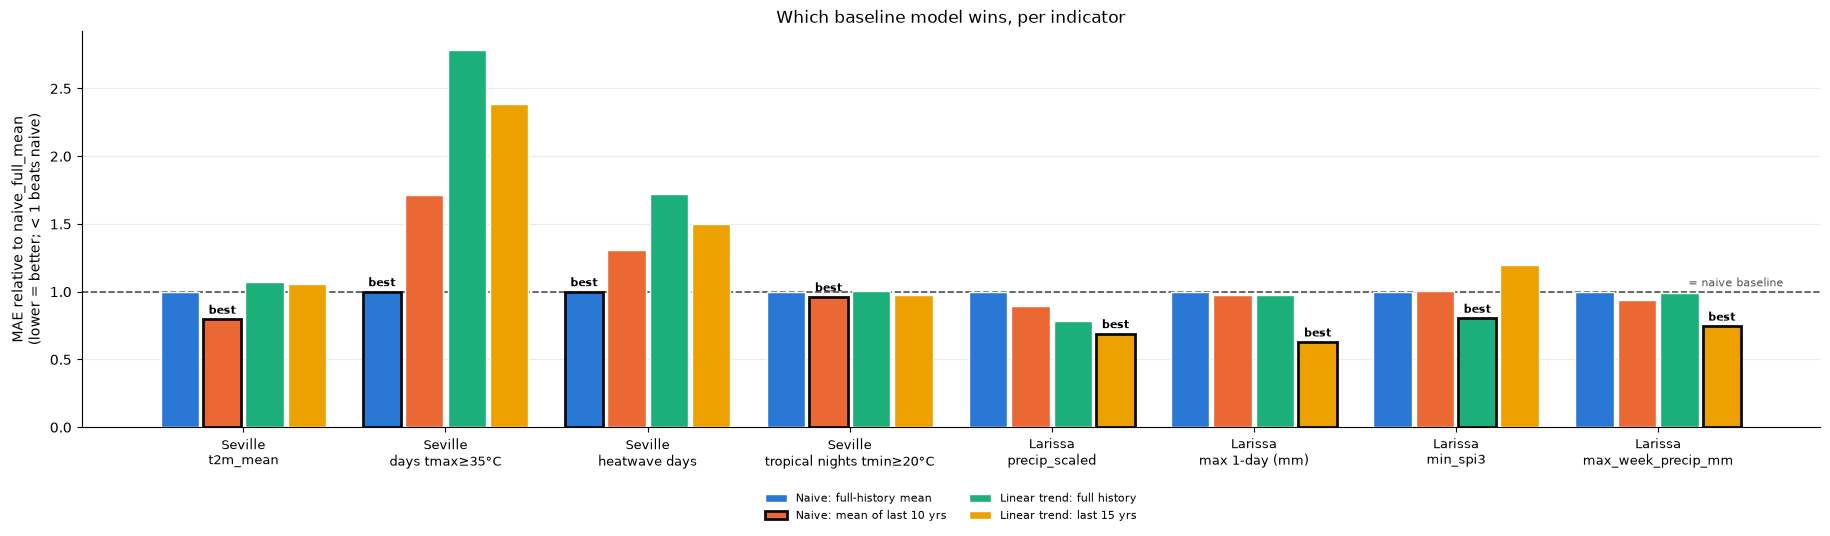

In [7]:
MODEL_ORDER = ["naive_full_mean", "mean_last_10yr", "ols_full_history", "ols_last_15yr"]
MODEL_LABELS = {
    "naive_full_mean": "Naive: full-history mean",
    "mean_last_10yr": "Naive: mean of last 10 yrs",
    "ols_full_history": "Linear trend: full history",
    "ols_last_15yr": "Linear trend: last 15 yrs",
}
# Validated categorical palette, fixed order (see dataviz color-formula) -- same
# color always means the same model, in every chart in this notebook.
MODEL_COLORS = {
    "naive_full_mean": "#2a78d6",
    "mean_last_10yr": "#eb6834",
    "ols_full_history": "#1baf7a",
    "ols_last_15yr": "#eda100",
}

n_ind = len(summary)
n_models = len(MODEL_ORDER)
x = np.arange(n_ind)
bar_width = 0.19

rel_mae = np.array([
    [summary.loc[i, f"{m}_MAE"] / summary.loc[i, "naive_full_mean_MAE"] for m in MODEL_ORDER]
    for i in summary.index
])
indicator_labels = [f"{row.city}\n{row.indicator}" for row in summary.itertuples()]

fig, ax = plt.subplots(figsize=(max(10, 2.3 * n_ind), 5.5))

for j, m in enumerate(MODEL_ORDER):
    offsets = x + (j - (n_models - 1) / 2) * (bar_width + 0.02)
    bars = ax.bar(offsets, rel_mae[:, j], width=bar_width, color=MODEL_COLORS[m],
                   edgecolor="white", linewidth=1, label=MODEL_LABELS[m], zorder=3)
    for i in range(n_ind):
        if summary.loc[i, "best_model"] == m:
            bars[i].set_edgecolor("#0b0b0b")
            bars[i].set_linewidth(2)
            ax.annotate("best", xy=(offsets[i], rel_mae[i, j]), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=8, fontweight="bold")

ax.axhline(1.0, color="#52514e", linestyle="--", linewidth=1.2, zorder=2)
ax.text(x[-1] + 0.62, 1.02, "= naive baseline", va="bottom", ha="right", fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels(indicator_labels, fontsize=9)
ax.set_ylabel("MAE relative to naive_full_mean\n(lower = better; < 1 beats naive)")
ax.set_title("Which baseline model wins, per indicator")
ax.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("baseline_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Next steps

- ~~Once SPI-3 is computed for Larissa, add it here as a target column~~ — done: `min_spi3`
  (drought depth) and `max_week_precip_mm` (flood intensity) from
  `Calculating_SPI_for_Larissa.ipynb` are now sections 4's 3rd and 4th Larissa indicators, testing
  the central volatility hypothesis (H4) directly rather than through the precipitation stand-ins.
  Notably, `ols_full_history` wins `min_spi3` — the first and only indicator across all 8 where the
  full-history trend beats every recency-restricted candidate, worth a sentence in the write-up
  since it cuts against the "recency always wins" pattern from the other 7.
- The fitted trend slopes here (`ols_full_history_slope_per_decade` and
  `ols_last_15yr_slope_per_decade`) are the historical baseline this project will compare against
  the actual SSP5-8.5 projection data in Week 3. Given the recency finding above, prefer
  `ols_last_15yr`'s slope as the "if current trends continue" baseline unless a specific reason
  favors the full-history fit for a given indicator.
- If a more sophisticated model is attempted later (e.g. polynomial trend, or a model with more
  predictors), each indicator's `best_model` in the `summary` table — not just the original two
  candidates — is the benchmark it needs to beat.